# ❤️ **회귀 심화**

## 20211357 오규원

---

### **1. 선형회귀**

---

#### (1) 다중선형회귀의 수식적 이해

$$
y_i = \beta_0+\beta_1X_{1i}+\beta_2X_{2i}+...+\beta_kX_{ki}+\varepsilon_i
$$

    => 알고자 하는 y 에 대해 영향을 줄 것 같은 여러 설명변수(독립변수)를 채택하여 선형적으로 작성한 식

$$
y=w_0x_0+w_1x_1+\cdot\cdot\cdot+w_mx_m=\sum_{i=0}^mw_ix_i=w^Tx
$$

    => 상수항과 오차항을 제외한 식

* 선형회귀식은 종속변수 y 에 대한 독립변수들의 가중평균으로도 표현 가능

* 설명변수에 가중치를 곱해 더함으로써 y를 얼마나 잘 설명하는지 나타낼 수 있음

---

#### (2) 다중선형회귀의 기본 가정 6가지

> 선형회귀는 다음 6가지 가정 하에서만 사용 가능

* **선형성(Linearity)**

    - $E(y|X) = \beta_1+\beta_2X_2+...+\beta_nX_n$

    - 종속변수와 설명변수 간의 관계가 선형적이어야 한다

* **독립성(Independence)**

    - $X_i, X_j \ is \ linearly\ independent \ for\ all \ i,j$

    - 각각의 설명변수가 서로 선형독립적(linearly independent)여야 함

    - 선형독립적이지 않으면 다중공선성이 있어 변수 제거, 규제 선형 모델, PCA 방법 사용해야함

* **오차항의 평균은 0이거나 0에 가까워야 한다**

    - $E(\varepsilon_i|X_i) = 0$ 

    - 오차항($\epsilon$) : 실제 값과 예측 값 사이 차이

    - 오차항 = White noise , white noise 의 성질을 만족하기 위해 필요한 가정

        - 백색 잡음은 랜덤 신호이므로 평균적으로 어느 방향에 치우치지 않아야 함

* **등분산성(Homoscedasticity)**

    - $Var(\varepsilon_i|X_i) = \sigma^2$

    - 오차항의 분산이 일정해야 함

        - 오차항의 분산이 일정하지 않은 경우, 이분산성이 있다고 함 -> 주로 횡단면 자료에서 많이 나타남
    
    - 등분산성을 알아보는 법

        - 잔차의 도표화

        - 검정(Brown-Forsythe, Breusch-Pagan)

* **오차항은 자기상관되어 있지 않다(Non-autocorrelation)

    - $Cov(\varepsilon_i, \varepsilon_j|X_i) =0$

    - 오차항의 공분산은 항상 0이어야 한다

    - 오차항의 공분산이 0 이 아니면 자기상관이 있다고 함

        - 자기상관 : 한 변수의 현재 값이 과거 값과 상관관계를 가지는 현상 -> 특히 시계열 자료에서 많이 나타남

        - 모델이 데이터를 랜덤하게 예측하는 것이 아닌 이전 데이터의 패턴을 학습하여 반복적인 오류를 만들어 낼 가능성이 높음

* **정규성(Normality), 선택**

    - $\varepsilon_i \sim N(0, \sigma^2)$

    - 오차항이 정규분포를 따른다

    - 정규성 가정은 위배되어도 다중선형회귀분석의 결과에 큰 영향 X

    - 회귀계수들의 신뢰구간과 p-value 를 계산할 때 사용되는 공식은 오차항이 정규분포를 따른다고 가정하고 만들어진 것이기에 정규분포 따라야 함.

    - 정규성을 알아보는 법

        - 샤피로-윌크 검정

        - 자퀴-베라 검정

        - Q-Q plot

##### 📌 **회귀 분석 전 vs 후 검증해야 할 가정**

| 기본 가정 | 회귀 분석 전에 검증 가능? | 회귀 분석 후에 검증 가능? | 검증 방법 |
| --- | --- | --- | --- |
| 선형성 | ✅ | ✅ | scattor plot 찍어보기 |
| 독립성 (다중공선성) | ✅ | ✅ | VIF 지수, 상관계수 |
| 오차항 평균이 0이다 | ❌ | ✅ | np.mean(residuals) |
| 등분산성 | ❌ | ✅ | 잔차의 도표화 |
| 오차항 자기상관 없다 | 🔺 (회귀 분석 전에는 간접적으로 검증 가능, 분석 후에 최종 검증) | ✅ | Durbin-Watson 검정(분석 후) |
| 정규성 | ❌  | ✅ | Shapiro-Wilk 검증, Q-Q plot |

분석 전 : '데이터'의 관계(가정 1, 2)

분석 후 : 모델이 틀린 정도인 '오차항'의 성질(가정 3~6)

---

#### (3) 회귀분석 평가 방법

* 시각화

    - 회귀선이 데이터 전반을 잘 요약함

    - 둘 중 어느 회귀선이 해당 데이터를 더 잘 요약하는지 객관적 비교 어려움

    - 통계지표 활용

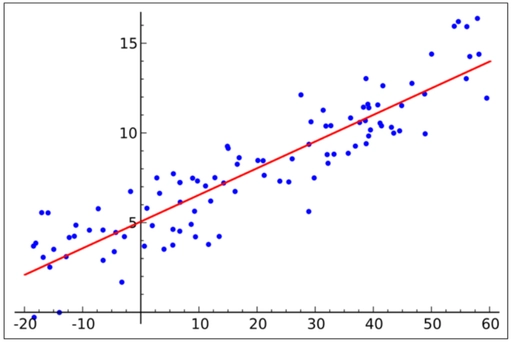

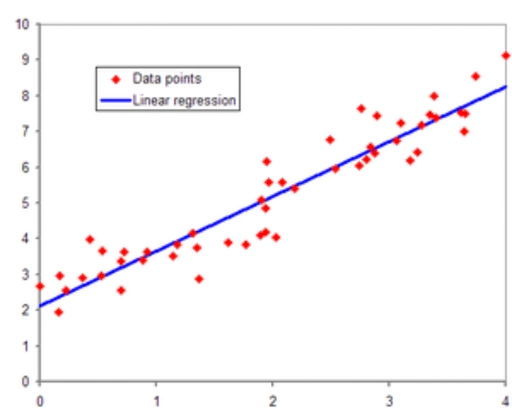


    

* 통계지표

    - 모델 유의성 검정

        - F-statistic, Prob(F-statistic) : 회귀 모델이 유의미한지 검정하는 지표

            - F-statistic 값이 클 수록 모델이 통계적으로 유의미함

            - Prob < 0.05 일 때 적어도 하나의 독립 변수가 종속 변수와 유의미한 관계를 갖고 있다

        - T-statistic, Prob(T-statistic)

            - 각 독립변수가 종속변수 y 에 유의미한 영향을 미치는지 판단하는 지표

    - 모델의 성능 평가

        - R-squared : 회귀 모델이 종속 변수의 전체 변동성을 얼마나 잘 설명하는가?

            - SST : 평균으로 예측했을 때의 총 오차

            - SSE : 모델이 예측하고도 여전히 남은 오차(모델의 한계)

            - SSR : 평균에 비해 Regression model 이 얼마나 더 잘 맞췄는가?(모델의 성과)

            - R-squared 가 1에 가까울 수록 SSR 과 SST 비슷해지고 SSE 는 0에 가까워짐

        - 조정된 결정 계수 :변수의 개수 증가에 덜 민감하도록 조정한 지표

            - $\overline{R}^2 = \frac{SSR}{SST}\frac{n-1}{n-k}=1-(\frac{SSE/(n-k)}{SST/(n-1)})$

            - ($n$: 샘플 수, $k$: 독립변수의 개수)

        - AIC, BIC(SC)

            - 정보 기준(information criteria) -> 값이 낮을 수록 좋다

            - AIC는 BIC 에 비해 복잡성에 대한 페널티 비교적 작음

            - BIC(SC) : AIC 보다 더 엄격한 기준으로 데이터의 양에 따라 더 강한 페널티 부과



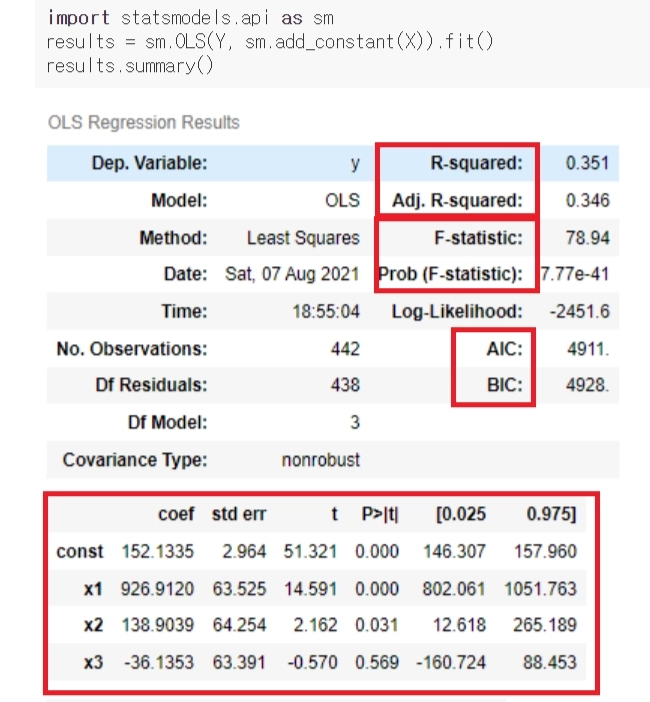



---

### **2. 비선형회귀**

---

#### (1) 다항식 회귀 모델(Polynomial Regression Model)

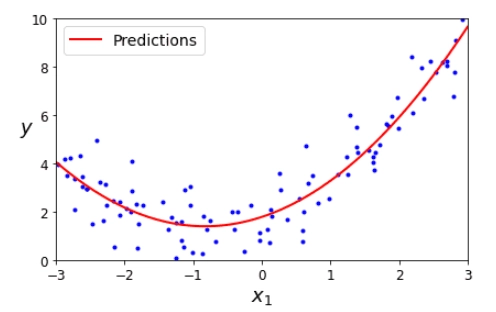

* 기존의 선형 회귀인 $Y=a+bX$ 이 아닌 $Y=a+bX+cX^2+dX^3+\cdot\cdot\cdot$의 형태로 독립 변수에 거듭제곱 항을 추가하여 데이터의 곡선적(비선형적) 특성을 모델링

* 사용 방법

    - 기존의 선형 모델1. $Y = a + bX$에 대해 $cX^2, dX^3$ 등을 포함하여 모델을 확장

    - 확장한 상태에 선형 회귀를 적용

* 적합한 상황

    - 관계가 직선적이지 않고 곡선을 그리는 데이터 패턴

    - 성장률, 감소율 등이 시간에 따라 변화하는 속도가 다른 경우

___

#### (2) 지수 회귀 모델(Exponential model)

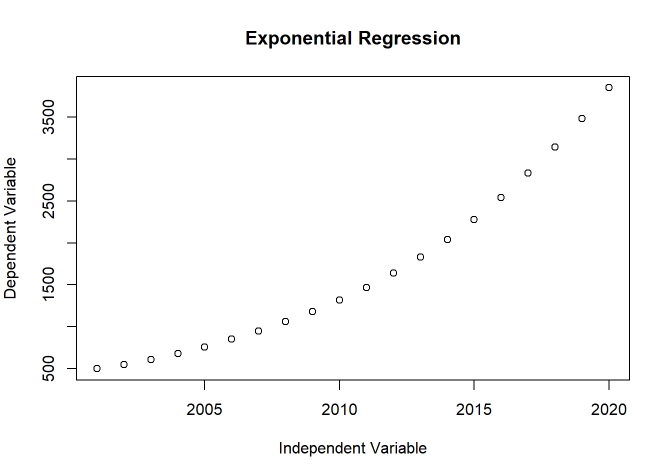

* 종속 변수가 지수적으로 변화하는 관계 모델링 할 때 사용


- 지수함수 형태의 데이터 : $Y = ae^{bX}$

- 양변에 로그를 취하면 $\ln Y=\ln a+bX$ , lnY를 Y’으로, ln a를 a’으로 본다면 Y’=a’+bX -> 종속 변수 Y 에 로그를 취한 후 선형회귀를 적용한 것.

- 계산된 Y' 은 $\ln Y$ 이기에 기존 데이터 형태로 복구하려면 예측 값에 지수함수 $(e^x)$ 를 적용

- 사용 방법

    - 종속 변수 Y 에 로그함수 적용

    - 로그 변환된 Y 와 기존의 독립변수 X에 대해 선형 회귀 적용 -> 모델이 ln Y(로그 변환된 Y)와 X의 선형 관계를 학습

    - Y 값 예측 시, 모델이 예측한 Y값에 지수함수를 적용하여 로그 변환하기 전 Y로 변형

- 적합한 상황

    - 값이 시간에 따라 지수적으로 증가하거나 감소하는 경우

    - 기술 발전, 투자 수익률 증가


---

#### (3) 로그 회귀 모델(log regression model)

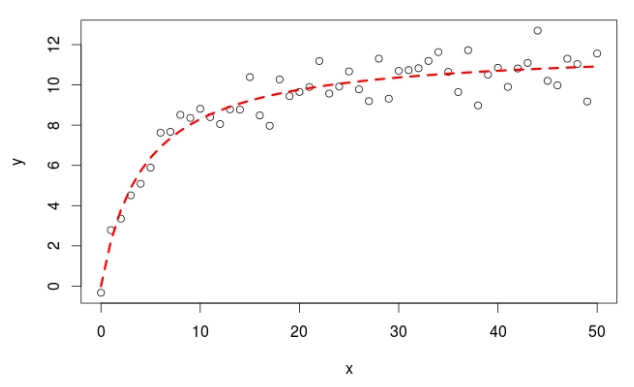

* 종속 변수와 독립 변수 간의 관계가 로그 함수를 통해 더 잘 표현될 때 사용 가능

* 사용 방법

    - 독립 변수 X 에 로그함수 적용

    - 선형 회귀 적용

    - 예측된 값은 Y 이므로 예측값에 별도의 처리를 하지 않고 그대로 사용 가능

> 로그함수 형태의 데이터는 $Y=a+b\log(X)$의 수식 따름 -> Y=a+bX의 선형식에서, X의 자리에 log(X)가 들어간 것 <br> <br>
***=> 독립 변수 X에 로그 연산을 취한 후, 나머지 과정은 선형 회귀와 동일***

---

#### (4) 스플라인 회귀(Spline Regression)

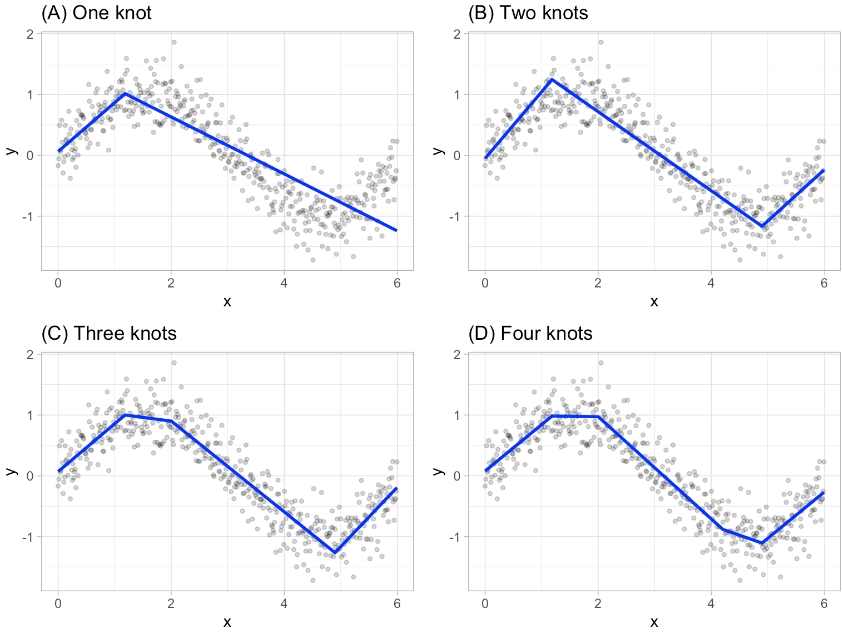

* 데이터를 구간별로 나누고 각 구간에서 다른 성형 또는 비선형 함수를 적용하여 예측

* 사용 방법 

    - 전체 데이터 범위를 여러 구간으로 나누고, 각 구간에 대해 별도의 회귀모델(선형, 다항 등) 적용

    - 구간 경계에서의 연속성을 유지하는 것이 중요

    - - $Y = \begin{cases} a_1 + b_1X & \text{if } X < c_1 \\a_2 + b_2X & \text{if } c_1 \leq X < c_2 \\\cdots \\a_n + b_nX & \text{if } X \geq c_{n-1}\end{cases}$

    - 적합한 상황

        - 데이터 패턴이 여러 구간에서 서로 다르게 나타날 때 

        - 계절에 따라 판매량이 변화하는 소매 데이터 분석

---